In [17]:
import PIL.Image as image
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

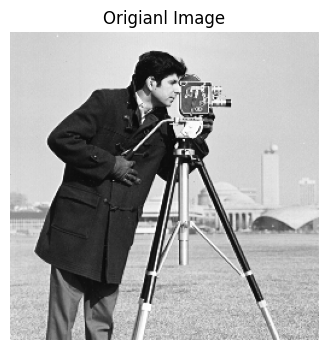

In [18]:
gray_img = image.open('./images/cameraman.bmp').convert('L')
img = np.array(gray_img)

H,W= img.shape

plt.figure(figsize=(10,4))
plt.imshow(gray_img, cmap='gray')
plt.title("Origianl Image")
plt.axis('off')

In [19]:
filter = np.array([[0,1,0],
                  [1,-4,1],
                  [0,1,0]])

In [20]:
padded_img = np.pad(img, pad_width = 1, mode = 'edge')

In [21]:
laplacian_edges = np.zeros_like(img, dtype = float)

for i in range (H):
    for j in range(W):
        region = padded_img[i:i+3,j:j+3]
        laplacian_edges[i,j] = np.sum(region * filter)

sharpen_image = img - laplacian_edges

laplacian_edges = np.clip(laplacian_edges, 0, 255).astype(np.uint8)
sharpen_image = np.clip(sharpen_image, 0, 255).astype(np.uint8)

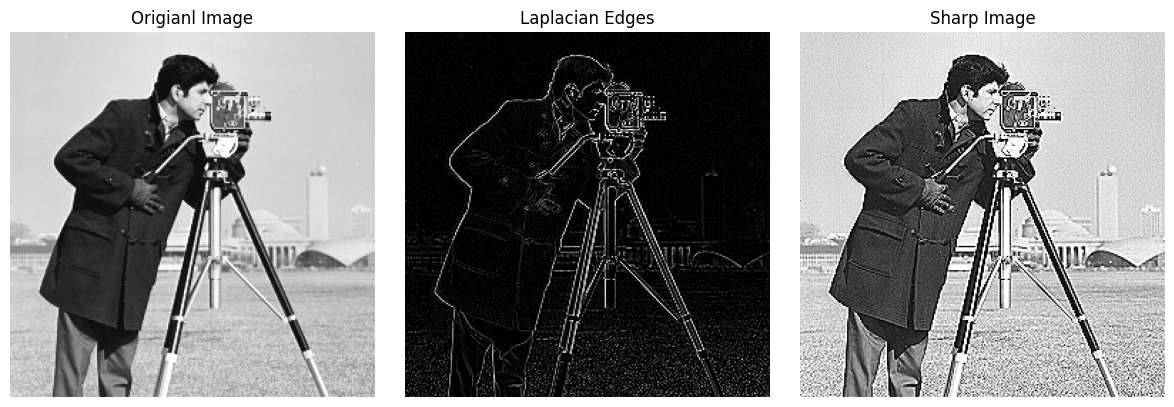

In [22]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Origianl Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(laplacian_edges, cmap='gray')
plt.title("Laplacian Edges")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(sharpen_image, cmap='gray')
plt.title("Sharp Image")
plt.axis('off')
plt.tight_layout()
plt.show()

In [23]:
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

In [24]:
gx = np.zeros_like(img, dtype=float)
gy = np.zeros_like(img, dtype=float)
gradient_magnitude = np.zeros_like(img, dtype=float)

padded_img = np.pad(img, pad_width=1, mode='constant', constant_values=0)

for i in range(H):
    for j in range(W):
        region = padded_img[i:i+3, j:j+3]
        gx[i, j] = np.sum(region * sobel_x)
        gy[i, j] = np.sum(region * sobel_y)

gradient_magnitude = np.sqrt(gx**2 + gy**2)

gx = np.clip(np.abs(gx), 0, 255).astype(np.uint8)
gy = np.clip(np.abs(gy), 0, 255).astype(np.uint8)
gradient_magnitude = np.clip(gradient_magnitude, 0, 255).astype(np.uint8)

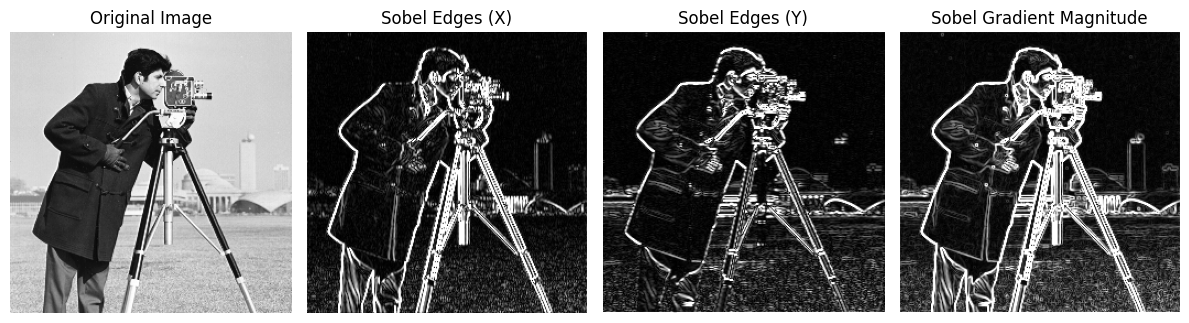

In [25]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(gx, cmap='gray')
plt.title("Sobel Edges (X)")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(gy, cmap='gray')
plt.title("Sobel Edges (Y)")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title("Sobel Gradient Magnitude")
plt.axis('off')
plt.tight_layout()
plt.show()